<a href="https://colab.research.google.com/github/Le2se0hy/FA_ProAn/blob/main/%ED%95%B8%EC%A6%88%EC%98%A8%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D_3%EC%9E%A5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 핸즈온 머신러닝_3장 [분류]

0210(화) - p.143 ~ 146

---

## 3.1 MNIST

- MNIST 데이터셋 : 손으로 쓴 70,000개의 작은 숫자 이미지. 각 이미지에는 어떤 숫자를 나타내는지 레이블되어 있고 학습용으로 아주 많이 사용됨



In [13]:
# OpenML.org에서 MNIST를 내려받는 코드

from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

sklearn.datasets 패키지에 있느느 세 종류의 함수
- fetch_* : fetch_openml()과 같이 실전 데이터셋을 다운로드하는 함수
- load_* : 사이킷런에 번들로 포함된 소규모 데이터셋을 로드하기 위한 함수 (인터넷에서 다운로드 필요x)
- make_* : 테스트에서 유용한 가짜 데이터셋을 생성하기 위한 함수. 생성된 데이터셋을 보통 넘파이 배열이고 (X,y) 튜플로 반환됨

sklearn.utils.Bunch 객체로 반환되는 데이터셋도 있는데 이 객체는 다음과 같은 항목을 참조할 수 잇는 딕셔너리
- DESCR : 데이터셋 설명
- data : 입력 데이터. 일반적으로 2D 넘파이 배열
- target : 레이블. 일반적으로 1D 넘파이 배열

fetch_openml() 함수는 기본적으로 입력을 판다스 데이터프레임, 레이블을 판다스 시리즈로 반환함.

하지만 MNIST 데이터셋은 이미지이므로 데이터프레임이 잘 맞지 않음. → as_frame=False로 지정하여 넘파이 배열로 데이터를 받음

In [14]:
X, y = mnist.data, mnist.target
X
# array([[0, 0, 0, ..., 0, 0, 0],
#       [0, 0, 0, ..., 0, 0, 0],
#       [0, 0, 0, ..., 0, 0, 0],
#       ...,
#       [0, 0, 0, ..., 0, 0, 0],
#       [0, 0, 0, ..., 0, 0, 0],
#       [0, 0, 0, ..., 0, 0, 0]])

X.shape
# (70000, 784)

y
# array(['5', '0', '4', ..., '4', '5', '6'], dtype=object)

y.shape
#
# (70000,)

(70000,)

이미지가 70,000개 있고 각 이미지에 784개의 특성이 있음 = 이미지가 28x28 픽셀이기 때문

각각의 특성은 단순히 0(흰색) ~ 255(검은색)까지의 픽셀 강도를 나타냄

데이터셋에서 이미지 하나를 확인해보자.

샘플의 특성 베터를 추출해서 28x28 배열로 크기를 바꾸고 맷플롯립의 imshow() 함수를 사용해 그리면 됨. cmap="binary"로 지정해 grayscale 맵을 사용

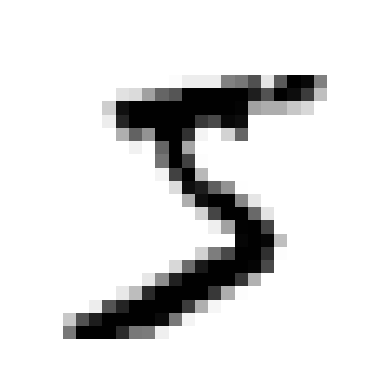

'5'

In [18]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
  image = image_data.reshape(28, 28)  # image_data는 보통 길이 784(=28×28)인 1차원 배열(벡터).
                                      # reshape(28, 28)은 그 벡터를 2차원 이미지 형태(28행 28열)로 바꾸는 것.

  plt.imshow(image, cmap="binary")
  plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)
plt.show()
y[0]

데이터를 자세히 조사하기 전에 항상 테스트 세트를 만들고 따로 떼어놓아야 함.

fetch_openml()이 반환한 MNIST 데이터셋은 이미 훈련 세트(앞쪽 60,000개)와 테스트 세트(뒤쪽 10,000개)로 나뉘어있음

In [ ]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

---
## 3.2 이진 분류기 훈련